In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("titanic")
numeric_cols = df.select_dtypes(include=["int64", "float64"])

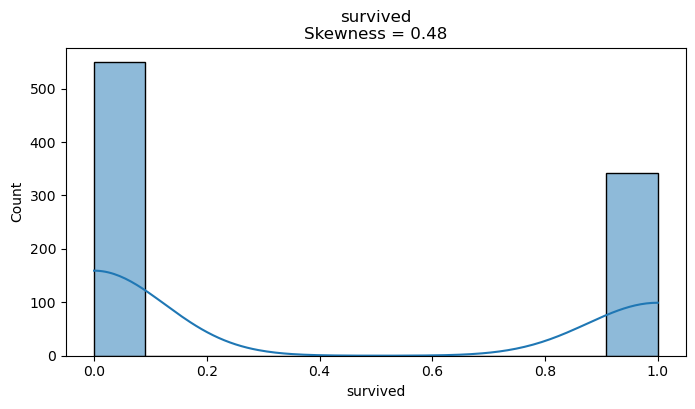

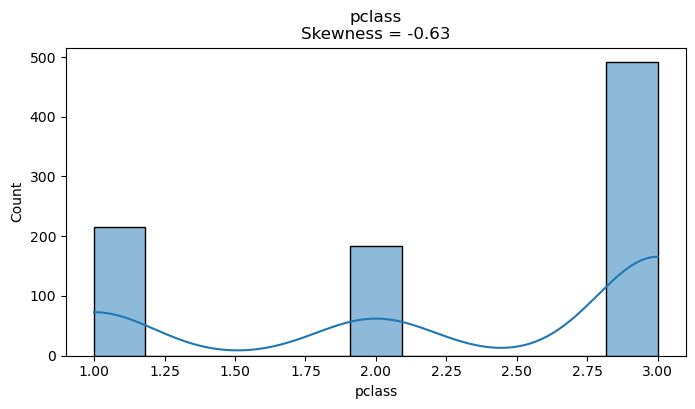

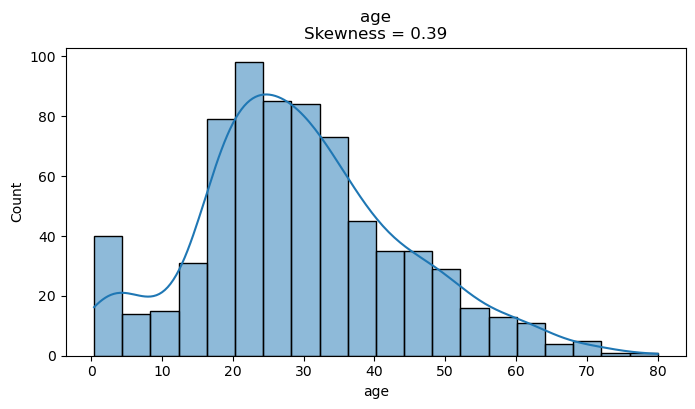

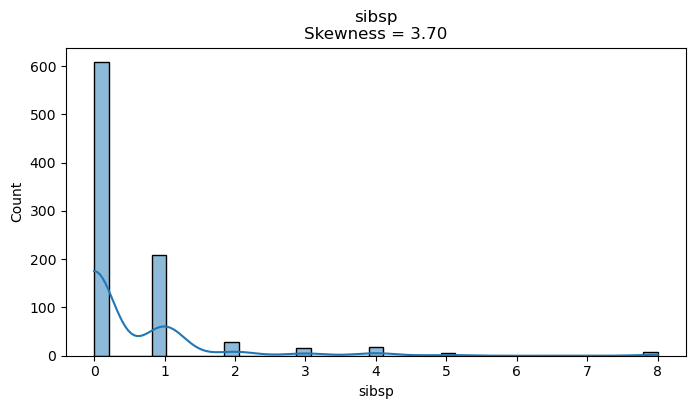

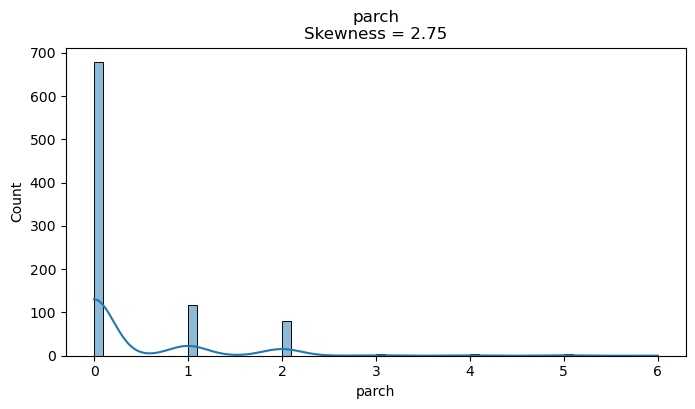

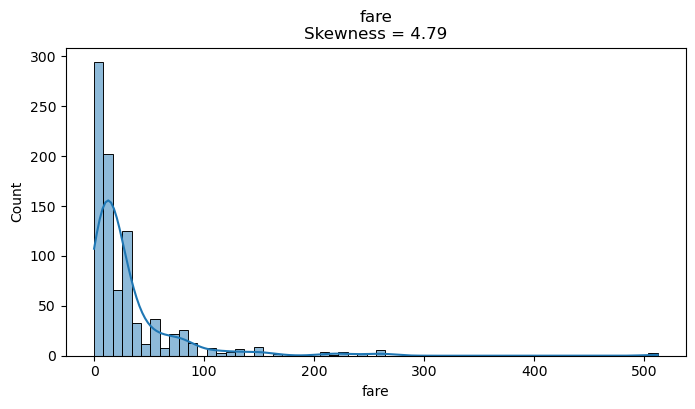

In [14]:
numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

for col in numeric_cols:

    skew = df[col].skew()

    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=col,
        kde=True
    )

    plt.title(
        f"{col}\nSkewness = {skew:.2f}"
    )

    plt.show()

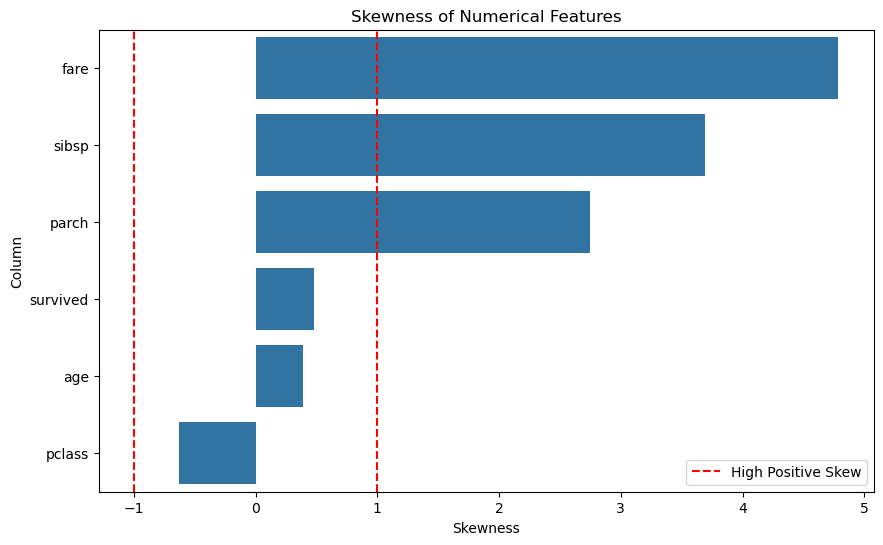

In [15]:
skew_df = pd.DataFrame({
    "Column": numeric_cols,
    "Skewness": [
        df[col].skew()
        for col in numeric_cols
    ]
})

skew_df = skew_df.sort_values(
    by="Skewness",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=skew_df,
    x="Skewness",
    y="Column"
)

plt.title("Skewness of Numerical Features")

plt.axvline(
    x=1,
    color="red",
    linestyle="--",
    label="High Positive Skew"
)

plt.axvline(
    x=-1,
    color="red",
    linestyle="--"
)

plt.legend()

plt.show()

In [16]:
from sklearn.preprocessing import PowerTransformer

print("old Skew:", df['sibsp'].skew())

pt = PowerTransformer(
    method="yeo-johnson"
)

df['sibsp_transformed'] = pt.fit_transform(
    df[["sibsp"]]
)

print("new skew:", df["sibsp_transformed"].skew())

old Skew: 3.6953517271630565
new skew: 0.8086080518632698


In [ ]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

sns.histplot(
    df["sibsp"],
    kde=True,
    ax=ax[0]
)
ax[0].set_title(f"Before  (skew={df['sibsp'].skew():.2f})")

sns.histplot(
    df["sibsp_transformed"],
    kde=True,
    ax=ax[1]
)
ax[1].set_title(f"After  (skew={df['sibsp_transformed'].skew():.2f})")

plt.tight_layout()
plt.show()

In [17]:
for col in numeric_cols:
    skew = df[col].skew()
    if abs(skew) > 1:
        print(f"{col}: {skew: .2f}")

sibsp:  3.70
parch:  2.75
fare:  4.79


In [18]:
df["fare_log"] = np.log1p(df["fare"])
print("fare log: ", df["fare_log"].skew())

fare log:  0.3949280095189306


In [20]:
from sklearn.preprocessing import PowerTransformer

print("old Skew:", df['sibsp'].skew())

pt = PowerTransformer(
    method="yeo-johnson"
)

df['sibsp_transformed'] = pt.fit_transform(
    df[["sibsp"]]
)

print("new skew:", df["sibsp_transformed"].skew())

old Skew: 3.6953517271630565
new skew: 0.8086080518632698


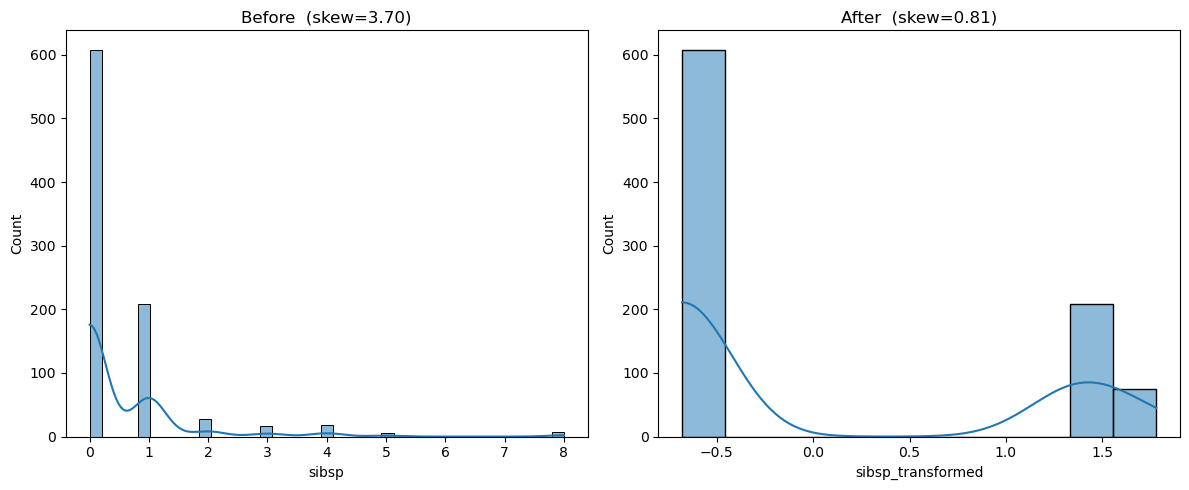

In [ ]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

sns.histplot(
    df["sibsp"],
    kde=True,
    ax=ax[0]
)
ax[0].set_title(f"Original  (skew={df['sibsp'].skew():.2f})")

sns.histplot(
    df["sibsp_transformed"],
    kde=True,
    ax=ax[1]
)
ax[1].set_title(f"yeo-jonson skew={df['sibsp_transformed'].skew():.2f})")

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import boxcox

print(
    "old:",
    df["fare"].skew()
)

df["fare_boxcox"], lam = boxcox(
    df["fare"]+1
)
print(
    "new:",
    df["fare_boxcox"].skew()
)


old: 4.787316519674893
new: -0.04032911572522667


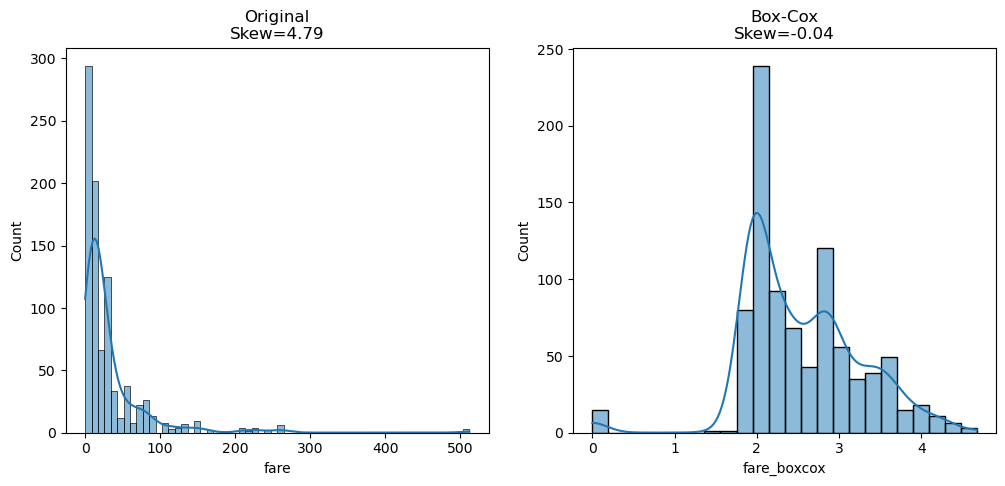

In [30]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

sns.histplot(
    df["fare"],
    kde=True,
    ax=ax[0]
)

ax[0].set_title(
    f"Original\nSkew={df['fare'].skew():.2f}"
)

sns.histplot(
    df["fare_boxcox"],
    kde=True,
    ax=ax[1]
)

ax[1].set_title(
    f"Box-Cox\nSkew={df['fare_boxcox'].skew():.2f}"
)

plt.show()

In [35]:
pt = PowerTransformer(method="yeo-johnson")

df["parch_transformed"] = pt.fit_transform(df[["parch"]])

print("old skew:", df["parch"].skew())
print("new skew:", df["parch_transformed"].skew())

old skew: 2.7491170471010933
new skew: 1.22879471917189


In [36]:
result = pd.DataFrame({
    "Features": [
        "sibsp",
        "parch",
        "fare"
    ],
    "old_skew": [
        df["sibsp"].skew(),
        df["parch"].skew(),
        df["fare"].skew()
    ],
    "new_skew": [
        df["sibsp_transformed"].skew(),
        df["parch_transformed"].skew(),
        df["fare_boxcox"].skew()
    ],
})

result

,Features,old_skew,new_skew
0,sibsp,3.695352,0.808608
1,parch,2.749117,1.228795
2,fare,4.787317,-0.040329
